# Redes neuronales densamente conectadas

## 1 - Imports

In [28]:
import tensorflow as tf #construye modelo
import numpy as np #crea o prepara datos de entrenamiento
import matplotlib.pyplot as plt #visualiza datos de entrenamiento y resultados del modelo

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 2 - Cargar el dataset MNIST
Train/Test split: Nunca se evalua un modelo con los datos de entrenamiento. El test set simula datos que la red nunca ha visto.

In [29]:
mnist = tf.keras.datasets.mnist #conjunto de datos de dígitos escritos a mano, con 60,000 imágenes de entrenamiento y 10,000 imágenes de prueba
(x_train, y_train), (x_test, y_test) = mnist.load_data() #carga el conjunto de datos MNIST y lo divide en conjuntos de entrenamiento y prueba. x_train y x_test contienen las imágenes, mientras que y_train y y_test contienen las etiquetas correspondientes a cada imagen.

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (60000, 28, 28), Test: (10000, 28, 28)


## 3 - Visualización de datos pixelados

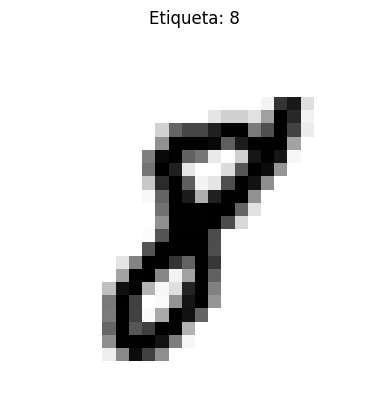

In [30]:
sample_idx = np.where(y_train == 8)[0][0] # encuentra el índice de la primera imagen en el conjunto de entrenamiento que tiene la etiqueta 8. np.where devuelve una tupla de arrays, donde el primer array contiene los índices de las imágenes que cumplen la condición (y_train == 8). Luego, se selecciona el primer índice [0][0] para obtener la posición de la primera imagen etiquetada como 8 en el conjunto de entrenamiento.
plt.imshow(x_train[sample_idx], cmap=plt.cm.binary) # muestra la imagen en escala de grises, donde los píxeles más oscuros representan valores más bajos, cercanos a 0 y los píxeles más claros representan valores más altos hasta 255
plt.title(f"Etiqueta: {y_train[sample_idx]}") # muestra la etiqueta de la imagen, que es el dígito que representa (en este caso, 8)
plt.axis("off") # oculta los ejes para una visualización más limpia de la imagen
plt.show() # muestra la imagen

## 4 - Visualización de pixeles en bruto
Configura las opciones de impresión de NumPy para mostrar los números con 2 decimales, suprimir la notación científica y establecer un ancho de línea de 120 caracteres para una mejor visualización de matrices grandes.

In [31]:
np.set_printoptions(precision=2, suppress=True, linewidth=120)
print(x_train[sample_idx])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  11 203 229  32   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  26  47  47  30  95 254 215  13   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  45 154 185 185 223 253 253 133 175 255 188  19   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 110 253 253 253 246 161 228 253 25

## 5 - Preprocesado
Las redes neuronales aprenden ajustando pesos con gradiente descendiente. Si los valores de entrada son muy grandes (255), los gradientes también son grandes e inestables. Con valores entre 0 y 1 el entrenamiento es más estable y rápido. Siempre normaliza tus datos de entrada.

In [32]:
# Aplanar: convierte cada imagen de 28x28 píxeles en un vector de 784 elementos (28*28=784)
# Normaliza los valores de píxeles dividiéndolos por 255.0 para que estén en el rango [0, 1], lo que facilita el entrenamiento del modelo.
x_train_flat = x_train.reshape((x_train.shape[0], 784)) / 255.0
x_test_flat  = x_test.reshape((x_test.shape[0], 784)) / 255.0

## 6 - Construcción del modelo
Modelo de una sola capa, clasificador lineal, esta capa tiene 10 neuronas, una para cada digito entre (0 - 9), utiliza la función de activación softmax para convertir las salidas en probabilidades.

**Dense (fully connected):** cada píxel de entrada está conectado a cada neurona de salida. No hay píxeles ignorados ni conexiones selectivas. Por eso también se llaman capas *fully connected*.

**Softmax:** convierte las salidas en probabilidades que suman 1. Solo se usa en la capa de salida de clasificadores multiclase. La neurona con mayor probabilidad es la predicción del modelo.

**model.summary():** muestra la arquitectura: tipo de capa, forma de salida y parámetros entrenables (784 entradas × 10 neuronas + 10 bias = **7.850 parámetros**).

**compile():**
-  — ajusta los pesos minimizando la pérdida de forma eficiente y adaptativa
-  — pérdida estándar para clasificación multiclase con etiquetas enteras (0-9)
-  — mide el % de predicciones correctas en cada epoch

**fit():**
-  — 10 pasadas completas sobre el dataset de entrenamiento
-  — reserva el 10% del training para medir si el modelo generaliza, sin usarlo para entrenar

**evaluate():** mide pérdida y accuracy final sobre el test set (datos que el modelo nunca vio durante el entrenamiento).

In [39]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax", name="output", input_shape=(784,))
])
model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(x_train_flat, y_train, epochs=5, validation_split=0.1)
model.evaluate(x_test_flat, y_test, verbose=2)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8724 - loss: 0.4889 - val_accuracy: 0.9243 - val_loss: 0.2751
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9127 - loss: 0.3136 - val_accuracy: 0.9317 - val_loss: 0.2454
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9183 - loss: 0.2919 - val_accuracy: 0.9363 - val_loss: 0.2349
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9216 - loss: 0.2808 - val_accuracy: 0.9368 - val_loss: 0.2299
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9233 - loss: 0.2732 - val_accuracy: 0.9357 - val_loss: 0.2292
313/313 - 0s - 1ms/step - accuracy: 0.9244 - loss: 0.2726


[0.27257680892944336, 0.9243999719619751]

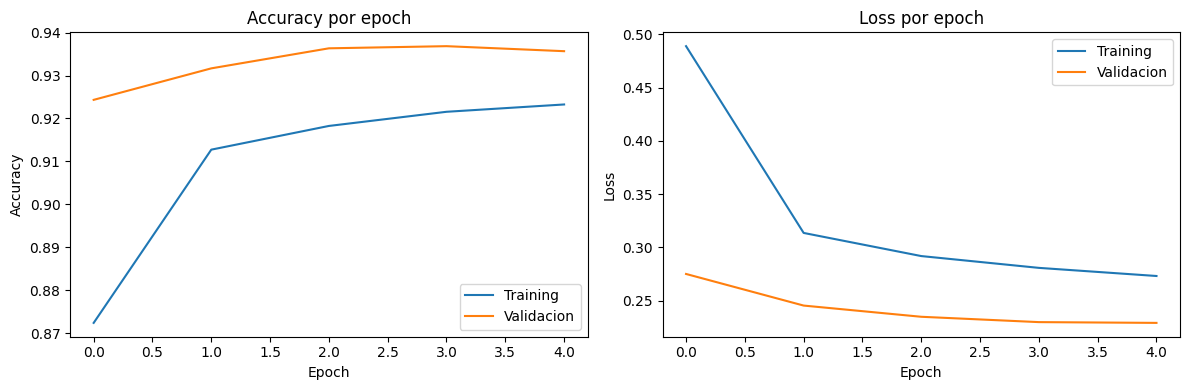

Training:   0.9233
Validacion: 0.9357
Gap:        -0.0124  OK - sin overfitting


In [40]:
# --- Deteccion de overfitting ---
# Si val_loss sube mientras training_loss baja = el modelo memoriza en vez de aprender
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"],     label="Training")
ax1.plot(history.history["val_accuracy"], label="Validacion")
ax1.set_title("Accuracy por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"],     label="Training")
ax2.plot(history.history["val_loss"], label="Validacion")
ax2.set_title("Loss por epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

train_acc = history.history["accuracy"][-1]
val_acc   = history.history["val_accuracy"][-1]
print(f"Training:   {train_acc:.4f}")
print(f"Validacion: {val_acc:.4f}")
print(f"Gap:        {train_acc - val_acc:.4f}  ", end="")
print("OK - sin overfitting" if (train_acc - val_acc) < 0.02 else "Posible overfitting")

In [41]:
def plot_learned_weights(model, digit: int) -> None:
    """Visualiza los pesos aprendidos para un dígito concreto."""
    weights = model.get_weights()[0]  # shape: (784, 10)
    weight_map = weights[:, digit].reshape(28, 28)
    plt.figure()
    plt.imshow(weight_map, cmap="seismic_r")
    plt.title(f"Pesos aprendidos para el dígito {digit}")
    plt.colorbar()
    plt.show()

Figura 4.14 Modelo aprendido correspondiente al número 7

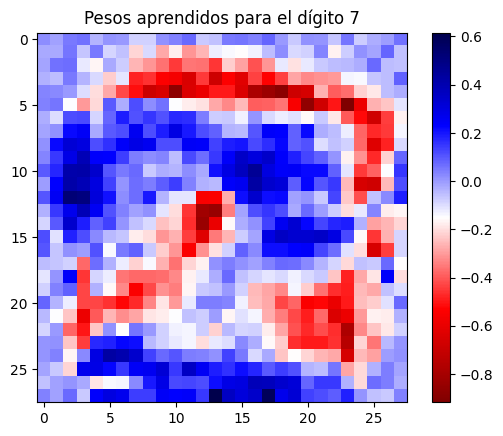

In [42]:
plot_learned_weights(model, digit=7)

Figura 4.5 Matriz de parámetros correspondiente al modelo de la categoría cero

In [43]:
weights = model.get_weights()[0]  # shape: (784, 10)
weight_map = weights[:, 0].reshape(28, 28)
np.set_printoptions(precision=0, suppress=True, linewidth=220)
print(np.round(255 * weight_map).astype(int))

[[ -20   16   22   20   11    8  -18   19   10    4  -17   17   -7    0  -23    9  -11  -13  -11  -14   -1    4  -12  -18   21    7  -11   15]
 [  19   -1   13   20   19    1   -9  -49  -12   -8  -56   22   32   21  -15   -3   11   14  -18  -49  -32   -7   -5  -20    7    1  -13   20]
 [  16  -22   -7   26   42  -49  -36  -10  -77 -120 -123  -82  -57 -113 -157 -167 -121 -163 -148 -108 -101  -95  -69  -59  -32   -7  -15  -12]
 [   3   -8  -19   46  -17  -56  -84  -87  -20  -60  -37  -13  -43  -26  -20  -24  -10  -17  -59 -100  -81 -138 -116  -45  -43  -29  -35  -11]
 [   1  -18  -34   25  -39  -95  -70  -15   10   10  -22   -6   -4   -9   -7   -8   -5   18   -9  -27  -18  -45  -36  -59  -52  -97  -35  -54]
 [  17   15  -52   10  -85 -111  -17  -23  -19  -30   10    0  -20   25   50   28    8   18   46   26  -27    5   -7  -42 -113 -162 -125  -37]
 [  14  -33  -40  -68  -96  -17   -3  -13  -26  -60   14    5   18   41   34   -4   40   54   40   30    5   30   48  -20 -118 -217 -104  -61]

Figura 4.16 Modelo aprendido correspondiente al número 5

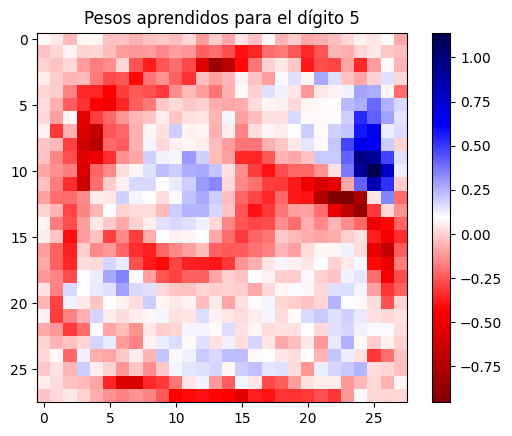

In [44]:
plot_learned_weights(model, digit=5)